# Word Embeddings

### Word2Vec · GloVe · fastText · Vector Space Visualization
---

## Goal

In Notebook 1, we hit a hard ceiling: no matter how cleverly we counted words,
two sentences with the same meaning but different vocabulary always scored zero
similarity. Counting methods are blind to meaning.

In this notebook we cross that line. Instead of counting words, we *learn*
a representation from data — a dense vector for every word that encodes not
just its identity but its **meaning**, based on the company it keeps in text.

For the first time, we will be able to *see* meaning as geometry:
`"cheating"` and `"plagiarism"` sitting close together in a 2D plot,
far from `"fridge"` and `"microwave"` — without ever being told they are related.

## Objectives

By the end of this notebook you will be able to:

- Train a **Word2Vec** model on a real corpus and inspect what it learned
- Retrieve nearest neighbors for any query word and interpret the results
- Reduce high-dimensional word vectors to **2D** and visualize semantic clusters
- Represent entire documents as vectors and compute **semantic similarity**
- Load and compare **GloVe** and **fastText** pre-trained embeddings
- Explain when and why each embedding model outperforms the others

## Dataset

> The same **91 Holberton School Zendesk articles** from Notebook 1,
> stored in `My Drive/nlp/docs/`. We will also observe how pre-trained
> embeddings trained on Wikipedia and Common Crawl compare to our
> small domain-specific corpus.

In [ ]:
# ── Libraries ─────────────────────────────────────────────────────────────────

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import nltk

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec
import gensim.downloader as gensim_api

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# ── Mount Drive ───────────────────────────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

# ── Load Documents ────────────────────────────────────────────────────────────

DOCS_PATH = '/content/drive/MyDrive/nlp/docs'
STOP_WORDS = set(stopwords.words('english'))

def preprocess(text):
    """Same pipeline as Notebook 1."""
    text = text.lower()
    text = re.sub(r'http\S+',    '', text)
    text = re.sub(r'[#*_>\-`]', '', text)
    text = re.sub(r'[^a-z\s]',  '', text)
    text = re.sub(r'\s+',       ' ', text)
    tokens = text.strip().split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return tokens

corpus = []
for fname in sorted(os.listdir(DOCS_PATH)):
    if fname.endswith('.md'):
        fpath = os.path.join(DOCS_PATH, fname)
        with open(fpath, 'r', encoding='utf-8') as f:
            raw = f.read()
        tokens = preprocess(raw)
        corpus.append({
            'filename'   : fname,
            'text'       : raw,
            'tokens'     : tokens,
            'clean_text' : ' '.join(tokens)
        })

print(f"✓ Loaded {len(corpus)} documents")
print(f"✓ Total tokens : {sum(len(d['tokens']) for d in corpus):,}")

# ── Topic Clusters ────────────────────────────────────────────────────────────
# We define known topic groups for use in visualizations throughout the notebook

CLUSTERS = {
    'Academic Integrity' : [
        'Cheating-Overview.md', 'Cheating-Examples.md',
        'AcademicStanding.md', 'StudentDismissal.md',
        'StudentDismissal-Academic.md', 'StudentDismissal-Behavioral.md',
    ],
    'Interviews & Career': [
        'MockInterviews.md', 'MockInterviews-FAQ.md',
        'MockInterviews-Help.md', 'MockInterviews-Pairing.md',
        'MockInterviews-Process.md', 'MockInterviews-Scripts.md',
    ],
    'Campus Duties'      : [
        'ChiefKitchenOfficer.md', 'ChiefAudio_VideoOfficer.md',
        'ChiefOpen-SpaceOfficer.md', 'ChiefOfficerDuties.md',
        'ChiefFeedbackOfficerDuty.md',
    ],
    'Remote Work'        : [
        'WorkingRemotely-Communication.md', 'WorkingRemotely-TimeManagement.md',
        'WorkingRemotely-CreatingSpace.md', 'WorkingRemotely-SettingBoundaries.md',
        'WorkingRemotely-Purpose&Routine.md',
    ],
    'Curriculum'         : [
        'CurriculumOverview.md', 'CurriculumFAQ.md', 'CurriculumFAQ2.md',
        'CurriculumFAQ3.md', 'CurriculumFAQ4.md', 'CurriculumFAQ5.md',
        'CurriculumFAQ6.md', 'TheFramework.md',
    ],
    'Events'             : [
        'Events.md', 'Events-Hackathons.md', 'Events-FiresideChats.md',
        'Events-TechnicalPresentations.md', 'HackDay.md',
    ],
    'Project Scoring'    : [
        'ProjectScoring.md', 'ProjectScoring-FAQ.md', 'ProjectScoring-FAQ2.md',
        'ProjectScoring-Grades.md', 'ProjectScoring-Checker.md',
        'ProjectScoring-GitHub.md', 'ProjectScoring-BrokenChecker.md',
        'ProjectScoring-CheckTypes.md', 'ProjectScoring-Contribution.md',
        'ProjectScoring-OptionalProjects.md', 'ProjectScoring-Regrades.md',
        'ProjectScoring-TaskLevel.md',
    ],
    'Specializations'    : [
        'Specializations.md', 'Specializations-FAQ.md', 'Specializations-FAQ1.md',
        'Specializations-FAQ2.md', 'Specializations-FAQ3.md',
        'Specializations-FAQ4.md', 'SpecializationValidation.md',
        'SpecializationValidation-Criteria.md',
    ],
}

CLUSTER_COLORS = {
    'Academic Integrity' : 'crimson',
    'Interviews & Career': 'steelblue',
    'Campus Duties'      : 'darkorange',
    'Remote Work'        : 'mediumseagreen',
    'Curriculum'         : 'mediumpurple',
    'Events'             : 'goldenrod',
    'Project Scoring'    : 'deeppink',
    'Specializations'    : 'teal',
    'Other'              : 'lightgrey',
}

# Attach cluster label to each document
doc_to_cluster = {doc: cluster
                  for cluster, docs in CLUSTERS.items()
                  for doc in docs}

for doc in corpus:
    doc['cluster'] = doc_to_cluster.get(doc['filename'], 'Other')

cluster_counts = pd.Series([doc['cluster'] for doc in corpus]).value_counts()
print(f"\n✓ Topic cluster distribution:\n")
for cluster, count in cluster_counts.items():
    print(f"  {cluster:<25} {count} documents")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Loaded 91 documents
✓ Total tokens : 8,079

✓ Topic cluster distribution:

  Other                     36 documents
  Project Scoring           12 documents
  Specializations           8 documents
  Curriculum                8 documents
  Academic Integrity        6 documents
  Interviews & Career       6 documents
  Campus Duties             5 documents
  Events                    5 documents
  Remote Work               5 documents


## Step 1: Training Word2Vec on the Holberton Corpus

We now train our first embedding model directly on the 91 Holberton documents.
Unlike everything in Notebook 1, Word2Vec does not count words — it **learns**
a dense vector for every word by training a neural network to predict words
from their neighbors.

We use the **Skip-gram** strategy: given a center word, predict the surrounding
context words. As the model trains, words that appear in similar contexts
naturally drift toward each other in the vector space.

A few key settings to be aware of:

- **vector_size:** How many dimensions each word vector has. We use 100.
- **window:** How many words left and right define the context. We use 5.
- **min_count:** Words appearing fewer than this many times are ignored.
  We use 1 to keep every word given our small corpus.
- **sg=1:** Tells gensim to use Skip-gram (sg=0 would use CBOW).
- **epochs:** How many times the model reads through the full corpus.

> **Note on corpus size:** 91 short documents is a small corpus for Word2Vec.
> In production, models are trained on billions of words. Our results will
> still be meaningful and educational — but the pre-trained models we load
> in Step 4 will show noticeably richer neighborhoods.

✓ Training corpus : 91 documents
✓ Total tokens    : 8,079

Sample — 'Cheating-Overview.md':
['cheating', 'kind', 'goes', 'spirit', 'purpose', 'time', 'holberton', 'absolutely', 'tolerated', 'taking', 'work', 'others', 'presenting', 'reflects', 'poorly'] ...

✓ Training complete
✓ Vocabulary size : 2,298 words
✓ Vector size     : 100 dimensions

Vector for 'cheating' (first 10 of 100 dimensions):
[ 0.2287 -0.5018  0.2922 -0.0125  0.3068 -0.105   0.1762 -0.2119  0.3499
 -0.0684]

── Nearest neighbors by cosine similarity ───────────────────────────

  'cheating'
   → 'disrespectful' (0.80),  'caught' (0.79),  'extremely' (0.77),  'behavior' (0.75),  'academically' (0.74)

  'interview'
   → 'finishing' (0.86),  'simulate' (0.84),  'accumulate' (0.83),  'early' (0.83),  'hiccups' (0.83)

  'remote'
   → 'joining' (0.93),  'explore' (0.84),  'participation' (0.83),  'webcam' (0.80),  'posted' (0.79)

  'kitchen'
   → 'showing' (0.96),  'maintained' (0.92),  'openspace' (0.92),  'storing' 

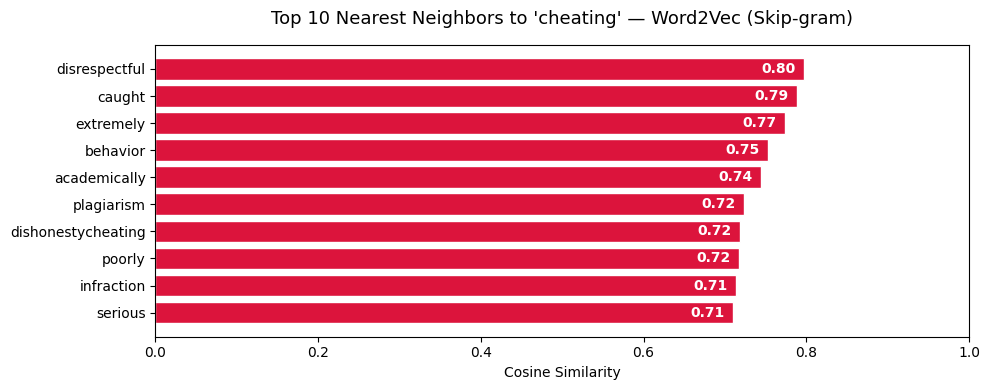

In [ ]:
# ── Prepare Token Lists for Word2Vec ─────────────────────────────────────────
# Word2Vec expects a list of token lists — one list per document

sentences = [doc['tokens'] for doc in corpus]

print(f"✓ Training corpus : {len(sentences)} documents")
print(f"✓ Total tokens    : {sum(len(s) for s in sentences):,}")
print(f"\nSample — '{corpus[3]['filename']}':")
print(sentences[3][:15], '...')

# ── Train Word2Vec ────────────────────────────────────────────────────────────

w2v_model = Word2Vec(
    sentences   = sentences,
    vector_size = 100,     # dimensions per word vector
    window      = 5,       # context window size
    min_count   = 1,       # include all words given small corpus
    sg          = 1,       # 1 = Skip-gram, 0 = CBOW
    epochs      = 50,      # more epochs compensates for small corpus
    seed        = 42,
)

vocab_size = len(w2v_model.wv)
print(f"\n✓ Training complete")
print(f"✓ Vocabulary size : {vocab_size:,} words")
print(f"✓ Vector size     : {w2v_model.vector_size} dimensions")

# ── Inspect a Word Vector ─────────────────────────────────────────────────────

sample_word = 'cheating'
vector      = w2v_model.wv[sample_word]

print(f"\nVector for '{sample_word}' (first 10 of {len(vector)} dimensions):")
print(np.round(vector[:10], 4))

# ── Nearest Neighbors ─────────────────────────────────────────────────────────

query_words = ['cheating', 'interview', 'remote', 'kitchen', 'scoring']

print(f"\n── Nearest neighbors by cosine similarity ───────────────────────────")
for word in query_words:
    if word in w2v_model.wv:
        neighbors = w2v_model.wv.most_similar(word, topn=5)
        neighbors_str = ',  '.join([f"'{w}' ({s:.2f})" for w, s in neighbors])
        print(f"\n  '{word}'")
        print(f"   → {neighbors_str}")

# ── Nearest Neighbors Bar Chart ───────────────────────────────────────────────

focus_word = 'cheating'
neighbors  = w2v_model.wv.most_similar(focus_word, topn=10)
words, scores = zip(*neighbors)

plt.figure(figsize=(10, 4))
bars = plt.barh(words[::-1], scores[::-1], color='crimson', edgecolor='white')
for bar, score in zip(bars, scores[::-1]):
    plt.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
             f'{score:.2f}', va='center', ha='right',
             color='white', fontsize=10, fontweight='bold')
plt.title(f"Top 10 Nearest Neighbors to '{focus_word}' — Word2Vec (Skip-gram)",
          fontsize=13, pad=15)
plt.xlabel('Cosine Similarity')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Step 2: Visualizing the Word Space in 2D

Each word in our vocabulary is currently a point in 100-dimensional space.
We cannot see 100 dimensions — but we can **compress** them down to 2 using
**PCA (Principal Component Analysis)**, which finds the two directions that
preserve the most variance in the data.

The result is a 2D map of meaning. Words that are close together in this
plot were close together in 100D space — which means the model learned to
associate them.

### A Note on Our Results

Our corpus has ~8,000 tokens across 91 short documents. Word2Vec is typically
trained on **billions** of words. With a small corpus, some neighbors will be
noisy — `"kitchen"` finding `"pictures"` as a neighbor makes sense only because
the kitchen document literally says *"below are pictures of what the kitchen
should look like"*. The model is doing its job; it just has limited evidence
to work with.

This is an important professional lesson: **the quality of embeddings is
directly proportional to the size and quality of the training corpus.**

To keep the plot readable and meaningful, we visualize a focused subset:
the most frequent words from each of our 8 topic clusters.

✓ Words selected for visualization : 92
  Academic Integrity        15 words
  Interviews & Career       12 words
  Campus Duties             14 words
  Remote Work               10 words
  Curriculum                12 words
  Events                    11 words
  Project Scoring           10 words
  Specializations           8 words

✓ PCA variance explained : 9.1% (PC1), 7.8% (PC2)


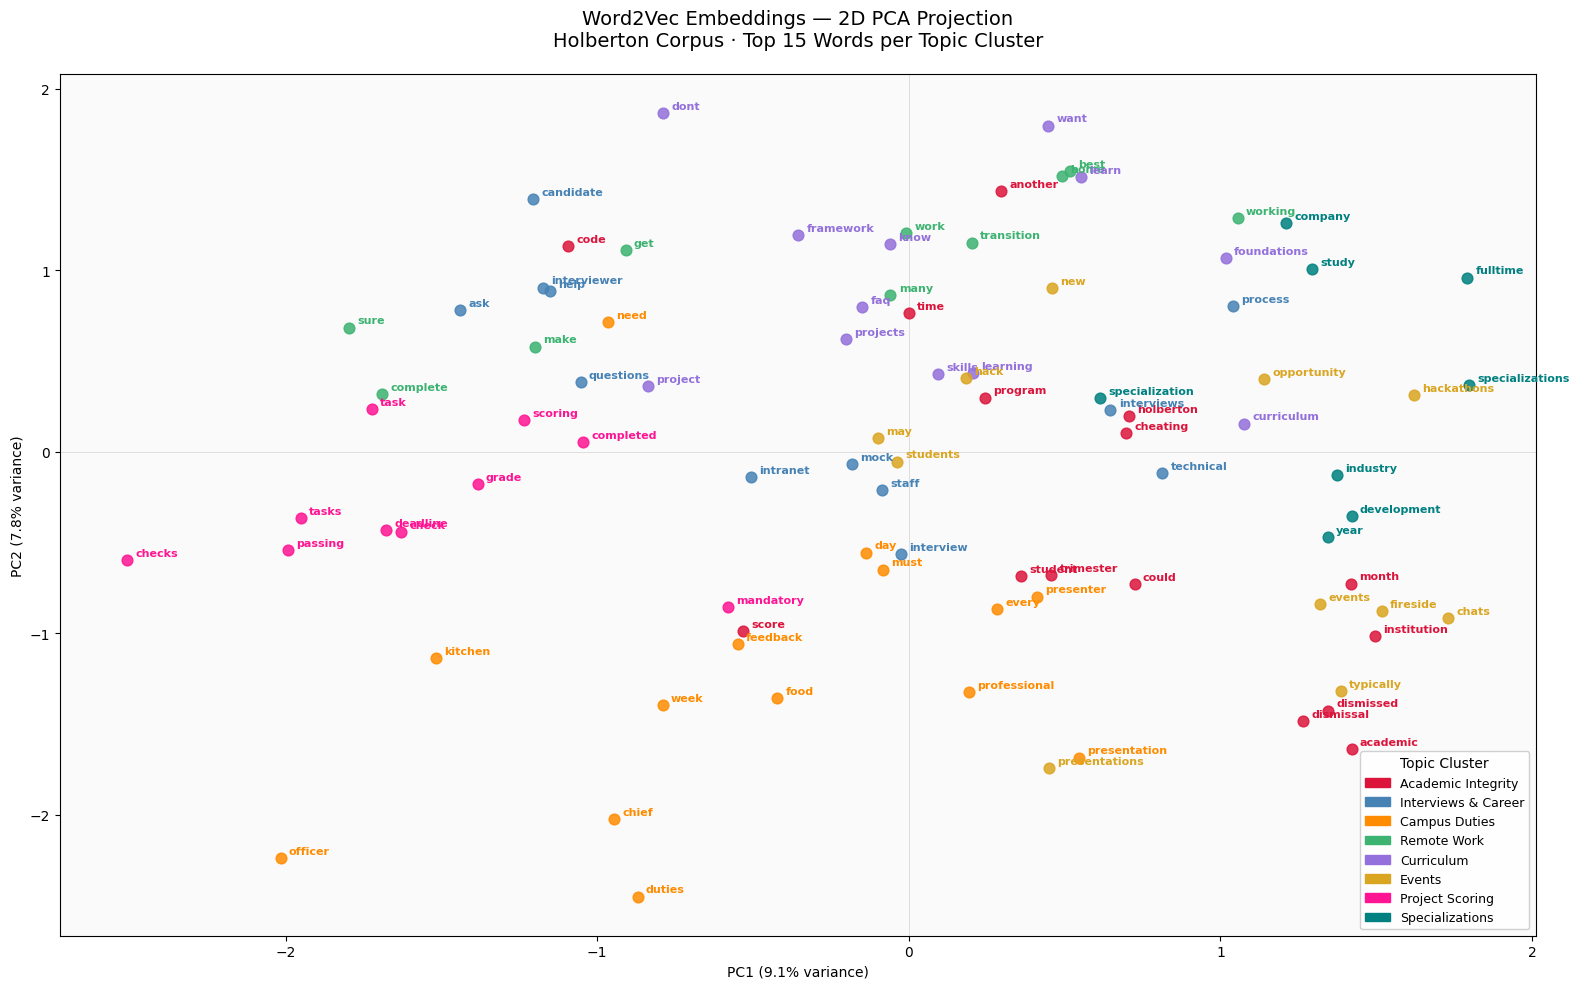

In [ ]:
# ── Select Representative Words Per Cluster ───────────────────────────────────

from collections import Counter

# Build a frequency map across the full corpus
all_tokens  = [t for doc in corpus for t in doc['tokens']]
freq        = Counter(all_tokens)

# For each cluster, collect tokens from its documents and pick top N
N_PER_CLUSTER = 15

cluster_words = {}  # cluster_name → list of (word, cluster)
for cluster, filenames in CLUSTERS.items():
    cluster_tokens = []
    for doc in corpus:
        if doc['filename'] in filenames:
            cluster_tokens.extend(doc['tokens'])
    # Keep only words in the Word2Vec vocabulary
    top_words = [
        w for w, _ in Counter(cluster_tokens).most_common(50)
        if w in w2v_model.wv
    ][:N_PER_CLUSTER]
    cluster_words[cluster] = top_words

# Flatten into a deduplicated list with cluster labels
seen    = set()
plot_words   = []
plot_labels  = []

for cluster, words in cluster_words.items():
    for word in words:
        if word not in seen:
            seen.add(word)
            plot_words.append(word)
            plot_labels.append(cluster)

print(f"✓ Words selected for visualization : {len(plot_words)}")
for cluster in CLUSTERS:
    count = plot_labels.count(cluster)
    print(f"  {cluster:<25} {count} words")

# ── Extract Vectors & Reduce to 2D ───────────────────────────────────────────

vectors = np.array([w2v_model.wv[w] for w in plot_words])

pca     = PCA(n_components=2, random_state=42)
coords  = pca.fit_transform(vectors)

print(f"\n✓ PCA variance explained : "
      f"{pca.explained_variance_ratio_[0]:.1%} (PC1), "
      f"{pca.explained_variance_ratio_[1]:.1%} (PC2)")

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 10))

for i, (word, label) in enumerate(zip(plot_words, plot_labels)):
    color = CLUSTER_COLORS.get(label, 'lightgrey')
    x, y  = coords[i]
    ax.scatter(x, y, color=color, s=60, alpha=0.85, zorder=2)
    ax.annotate(word, (x, y),
                fontsize=8,
                textcoords='offset points',
                xytext=(6, 3),
                color=color,
                fontweight='bold')

# Legend
legend_patches = [
    mpatches.Patch(color=CLUSTER_COLORS[c], label=c)
    for c in CLUSTERS
]
ax.legend(handles=legend_patches,
          loc='lower right',
          fontsize=9,
          framealpha=0.9,
          title='Topic Cluster',
          title_fontsize=10)

ax.set_title('Word2Vec Embeddings — 2D PCA Projection\n'
             'Holberton Corpus · Top 15 Words per Topic Cluster',
             fontsize=14, pad=20)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=10)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=10)
ax.axhline(0, color='lightgrey', linewidth=0.5, zorder=1)
ax.axvline(0, color='lightgrey', linewidth=0.5, zorder=1)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

## Step 3: Document Vectors — From Words to Documents

So far we have a vector for every **word**. But to compare entire **documents**
we need a single vector that represents the meaning of a whole document.

The simplest and most effective approach is **vector averaging**: take every
word in a document, look up its Word2Vec vector, and compute the mean. The
resulting vector sits at the centroid of all the words in that document —
a single point in 100-dimensional space that summarizes its meaning.

$$\vec{doc} = \frac{1}{N} \sum_{i=1}^{N} \vec{word_i}$$

This is not perfect — it loses word order and treats all words equally — but
it is a powerful and fast baseline. And crucially, **semantically similar
documents should now cluster together**, because their words live in similar
regions of the vector space.

We will visualize all 91 documents in 2D and see whether the model has learned
to group related documents — without ever being told their topic labels.

✓ Document vectors computed : (91, 100)  (documents × dimensions)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✓ t-SNE projection complete


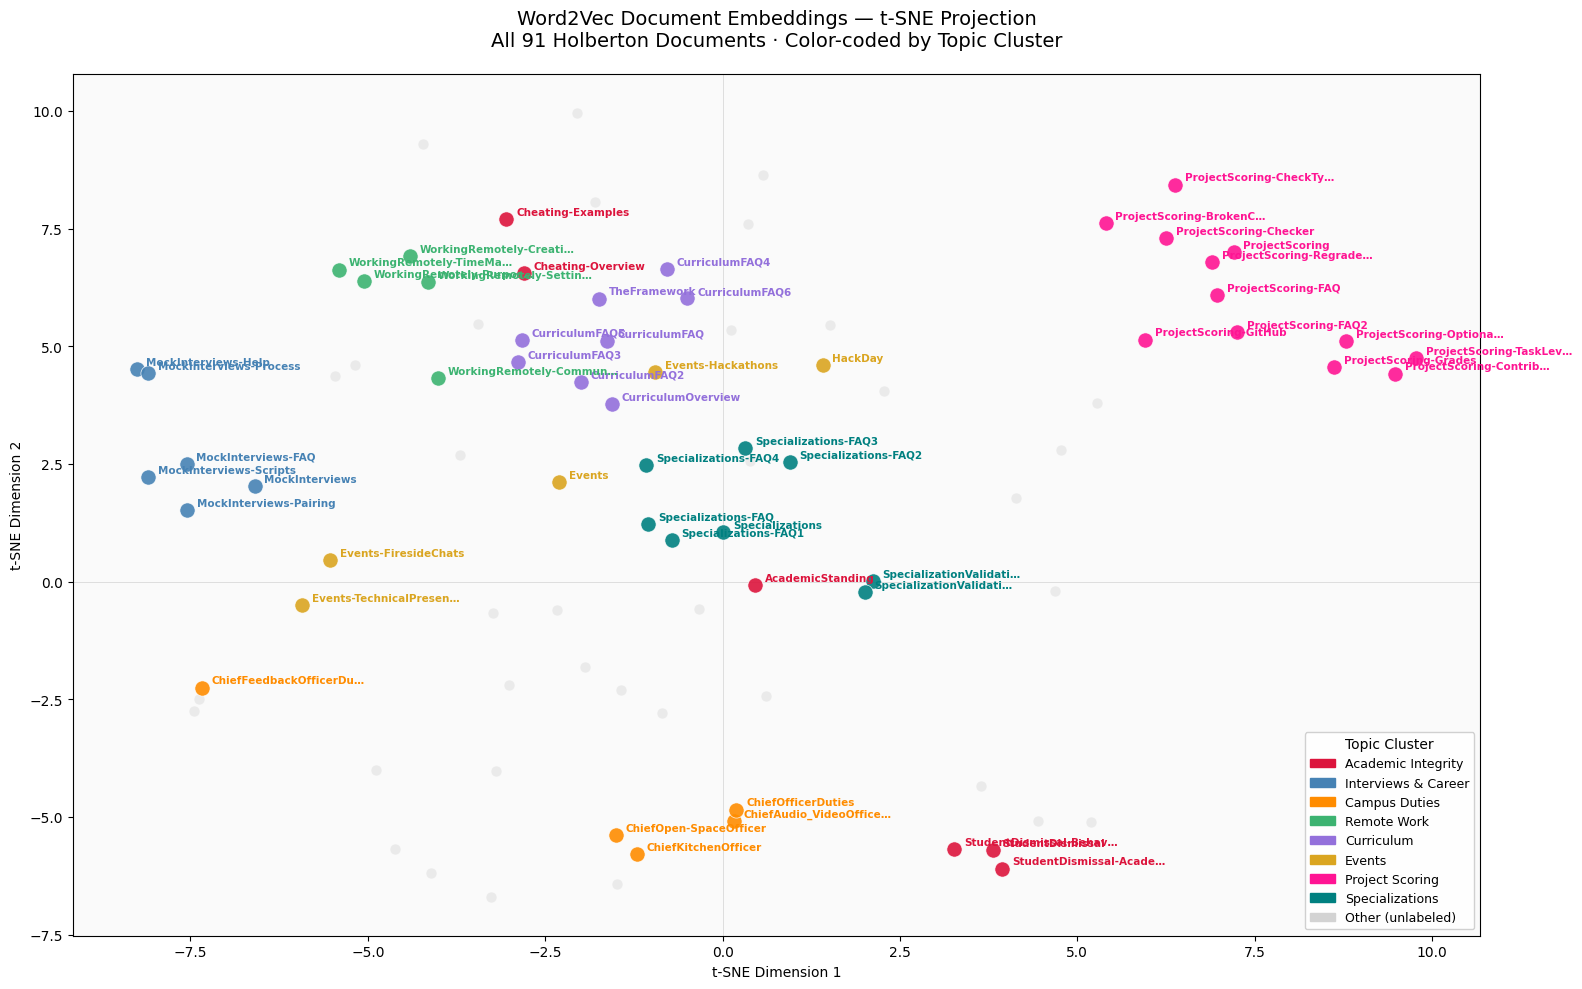

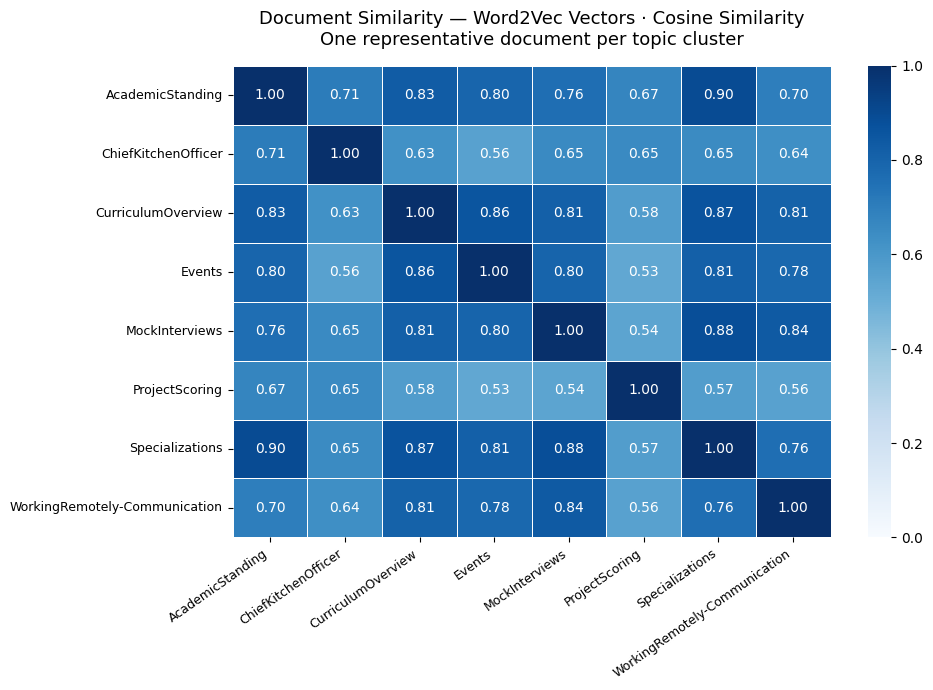

── Semantic similarity revisited ────────────────────────────────────

  A : 'students must maintain academic performance'
  B : 'learners need to keep up their grades'
  Word2Vec similarity : 0.48  ← was 0.00 with TF-IDF

  A : 'cheating will not be tolerated'
  B : 'plagiarism leads to expulsion'
  Word2Vec similarity : 0.79  ← was 0.00 with TF-IDF

  A : 'attend events to meet industry professionals'
  B : 'fireside chats are good networking opportunities'
  Word2Vec similarity : 0.82  ← was 0.00 with TF-IDF


In [ ]:
# ── Compute Document Vectors ──────────────────────────────────────────────────

from sklearn.manifold import TSNE

def document_vector(tokens, model):
    """Average the Word2Vec vectors of all tokens in a document."""
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

for doc in corpus:
    doc['vector'] = document_vector(doc['tokens'], w2v_model)

doc_vectors = np.array([doc['vector'] for doc in corpus])
doc_labels  = [doc['cluster']   for doc in corpus]
doc_names   = [doc['filename'].replace('.md', '') for doc in corpus]

print(f"✓ Document vectors computed : {doc_vectors.shape}  (documents × dimensions)")

# ── Reduce to 2D with t-SNE ───────────────────────────────────────────────────
# t-SNE is better than PCA for visualization — it preserves local cluster
# structure rather than global variance, producing tighter, more separated groups.
# Note: distances *between* clusters are not meaningful, only the clusters themselves.

tsne   = TSNE(n_components=2,
              perplexity=20,    # lower perplexity suits small datasets (~91 docs)
              n_iter=1000,
              random_state=42)
coords = tsne.fit_transform(doc_vectors)

print("✓ t-SNE projection complete")

# ── Full 91-Document Cluster Plot ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 10))

for i, (label, name) in enumerate(zip(doc_labels, doc_names)):
    color  = CLUSTER_COLORS.get(label, 'lightgrey')
    x, y   = coords[i]
    size   = 120 if label != 'Other' else 60
    alpha  = 0.90 if label != 'Other' else 0.40
    zorder = 3   if label != 'Other' else 1

    ax.scatter(x, y, color=color, s=size, alpha=alpha,
               edgecolors='white', linewidth=0.5, zorder=zorder)

    # Only annotate named clusters — Other would clutter the plot
    if label != 'Other':
        short = (name[:22] + '…') if len(name) > 22 else name
        ax.annotate(short, (x, y),
                    fontsize=7.5,
                    textcoords='offset points',
                    xytext=(7, 3),
                    color=color,
                    fontweight='bold',
                    zorder=4)

# Legend
legend_patches = [
    mpatches.Patch(color=CLUSTER_COLORS[c], label=c)
    for c in list(CLUSTERS.keys())
]
legend_patches.append(
    mpatches.Patch(color='lightgrey', label='Other (unlabeled)')
)
ax.legend(handles=legend_patches,
          loc='lower right',
          fontsize=9,
          framealpha=0.9,
          title='Topic Cluster',
          title_fontsize=10)

ax.set_title('Word2Vec Document Embeddings — t-SNE Projection\n'
             'All 91 Holberton Documents · Color-coded by Topic Cluster',
             fontsize=14, pad=20)
ax.set_xlabel('t-SNE Dimension 1', fontsize=10)
ax.set_ylabel('t-SNE Dimension 2', fontsize=10)
ax.axhline(0, color='lightgrey', linewidth=0.5, zorder=0)
ax.axvline(0, color='lightgrey', linewidth=0.5, zorder=0)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

# ── Document Similarity Heatmap ───────────────────────────────────────────────

sample_docs = [
    'AcademicStanding.md',
    'MockInterviews.md',
    'ChiefKitchenOfficer.md',
    'WorkingRemotely-Communication.md',
    'CurriculumOverview.md',
    'Events.md',
    'ProjectScoring.md',
    'Specializations.md',
]

sample_indices = [i for i, doc in enumerate(corpus)
                  if doc['filename'] in sample_docs]
sample_vectors = doc_vectors[sample_indices]
sample_labels  = [doc_names[i] for i in sample_indices]

sim_matrix = cosine_similarity(sample_vectors)
sim_df     = pd.DataFrame(sim_matrix,
                           index=sample_labels,
                           columns=sample_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(sim_df,
            annot=True, fmt='.2f',
            cmap='Blues',
            linewidths=0.5,
            vmin=0, vmax=1)
plt.title('Document Similarity — Word2Vec Vectors · Cosine Similarity\n'
          'One representative document per topic cluster',
          fontsize=13, pad=15)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.show()

# ── Semantic Similarity Fix: Revisiting Notebook 1 failures ───────────────────

print("── Semantic similarity revisited ────────────────────────────────────")
pairs = [
    ("students must maintain academic performance",
     "learners need to keep up their grades"),
    ("cheating will not be tolerated",
     "plagiarism leads to expulsion"),
    ("attend events to meet industry professionals",
     "fireside chats are good networking opportunities"),
]

for s1, s2 in pairs:
    v1    = document_vector(preprocess(s1), w2v_model).reshape(1, -1)
    v2    = document_vector(preprocess(s2), w2v_model).reshape(1, -1)
    score = cosine_similarity(v1, v2)[0][0]
    print(f"\n  A : '{s1}'")
    print(f"  B : '{s2}'")
    print(f"  Word2Vec similarity : {score:.2f}  ← was 0.00 with TF-IDF")

## Step 4: Pre-trained Embeddings — GloVe and fastText

So far we trained Word2Vec **from scratch** on 91 short documents. The results
were meaningful but noisy — because 8,079 tokens is a tiny training corpus.

The good news: we don't always need to train from scratch. Researchers have
already trained embedding models on **billions of words** and made them publicly
available. We can load these pre-trained vectors and immediately benefit from
their richer, more reliable representations.

We will load two models via `gensim.downloader`:

- **GloVe** (`glove-wiki-gigaword-100`) — trained on Wikipedia + Gigaword news.
  400,000 word vocabulary, 100-dimensional vectors.
- **fastText** (`fasttext-wiki-news-subwords-300`) — trained on Wikipedia.
  Handles out-of-vocabulary words by composing vectors from character subwords.

### The OOV Problem

Both Word2Vec and GloVe fail silently on words they have never seen — they
simply have no vector for them. This is the **out-of-vocabulary (OOV)** problem.

fastText solves this by breaking unknown words into character n-grams and
summing their subword vectors. Even a word it has never seen — a typo, a rare
name, a domain-specific term — gets a reasonable representation.

> **Note:** These models are large files (100MB–1GB). Gensim will download
> and cache them automatically on first run. This may take a few minutes.

In [ ]:
# ── Load Pre-trained GloVe ────────────────────────────────────────────────────

print("Loading GloVe (glove-wiki-gigaword-100) ...")
glove_model = gensim_api.load('glove-wiki-gigaword-100')
print(f"✓ GloVe loaded  : {len(glove_model):,} words · 100 dimensions")

# ── Load Pre-trained fastText ─────────────────────────────────────────────────

print("\nLoading fastText (fasttext-wiki-news-subwords-300) ...")
ft_model = gensim_api.load('fasttext-wiki-news-subwords-300')
print(f"✓ fastText loaded : {len(ft_model):,} words · 300 dimensions")


Loading GloVe (glove-wiki-gigaword-100) ...
✓ GloVe loaded  : 400,000 words · 100 dimensions

Loading fastText (fasttext-wiki-news-subwords-300) ...
✓ fastText loaded : 999,999 words · 300 dimensions


In [ ]:
# Nearest Neighbors: Same Query, Three Models
query_words = ['cheating', 'plagiarism', 'interview', 'remote']

print("\n── Nearest neighbors across three models ────────────────────────────")
for word in query_words:
    print(f"\n  '{word}'")

    # Word2Vec (our corpus)
    if word in w2v_model.wv:
        nn = w2v_model.wv.most_similar(word, topn=4)
        print(f"   Word2Vec  (Holberton) → {', '.join([w for w, _ in nn])}")

    # GloVe (Wikipedia + news)
    if word in glove_model:
        nn = glove_model.most_similar(word, topn=4)
        print(f"   GloVe     (Wikipedia) → {', '.join([w for w, _ in nn])}")

    # fastText (Wikipedia)
    if word in ft_model:
        nn = ft_model.most_similar(word, topn=4)
        print(f"   fastText  (Wikipedia) → {', '.join([w for w, _ in nn])}")


── Nearest neighbors across three models ────────────────────────────

  'cheating'
   Word2Vec  (Holberton) → disrespectful, caught, extremely, behavior
   GloVe     (Wikipedia) → fraud, cheats, plagiarism, admitting
   fastText  (Wikipedia) → cheat, cheater, cheats, cheaters

  'plagiarism'
   Word2Vec  (Holberton) → extremely, saying, natureseverity, rsvpd
   GloVe     (Wikipedia) → dishonesty, slander, misconduct, cheating
   fastText  (Wikipedia) → plagarism, self-plagiarism, Plagiarism, plagiarisms

  'interview'
   Word2Vec  (Holberton) → finishing, simulate, accumulate, early
   GloVe     (Wikipedia) → told, asked, news, reporters
   fastText  (Wikipedia) → pre-interview, interviews, interview-, post-interview

  'remote'
   Word2Vec  (Holberton) → joining, explore, participation, webcam
   GloVe     (Wikipedia) → mountainous, rugged, areas, isolated
   fastText  (Wikipedia) → non-remote, remote-, distant, remoter


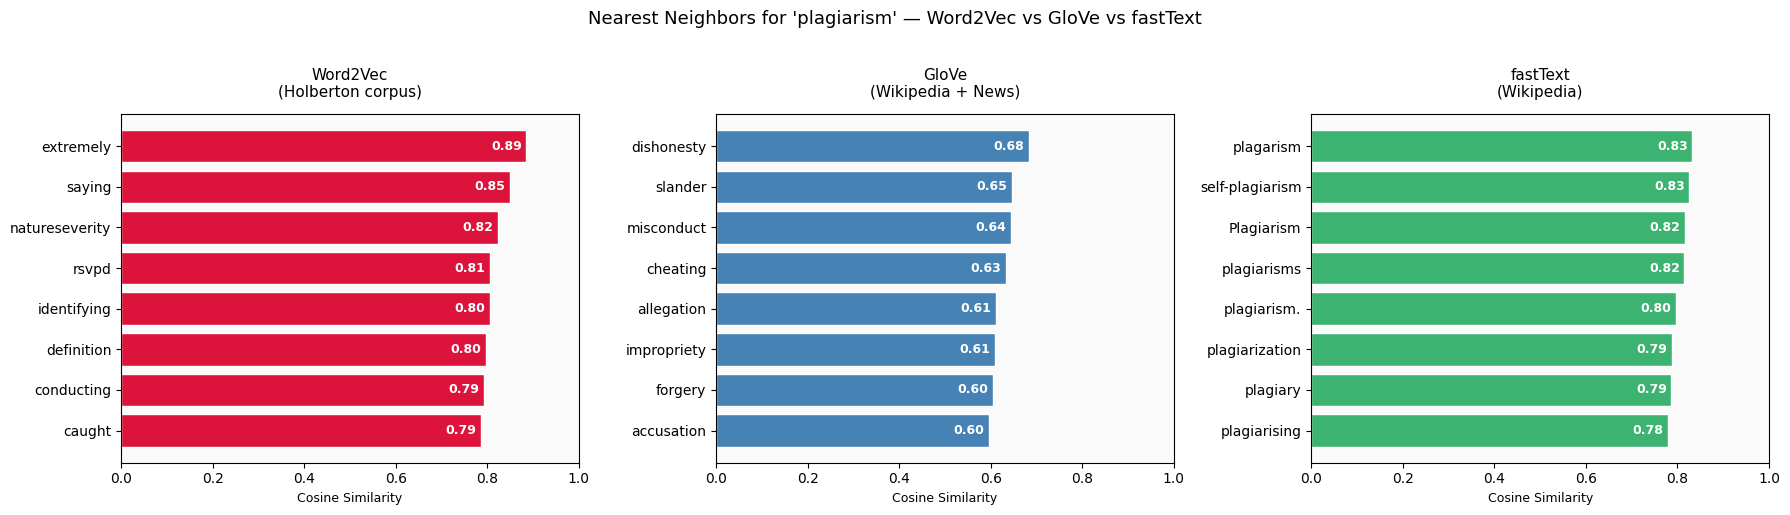

In [ ]:
# ── Side-by-Side Bar Chart: Three Models, One Query Word ─────────────────────

focus    = 'plagiarism'
topn     = 8
models   = {
    'Word2Vec\n(Holberton corpus)' : w2v_model.wv,
    'GloVe\n(Wikipedia + News)'   : glove_model,
    'fastText\n(Wikipedia)'        : ft_model,
}
colors   = ['crimson', 'steelblue', 'mediumseagreen']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, model_wv), color in zip(axes, models.items(), colors):
    if focus in model_wv:
        neighbors        = model_wv.most_similar(focus, topn=topn)
        words, scores    = zip(*neighbors)
        bars = ax.barh(words[::-1], scores[::-1],
                       color=color, edgecolor='white')
        for bar, score in zip(bars, scores[::-1]):
            ax.text(bar.get_width() - 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    f'{score:.2f}', va='center', ha='right',
                    color='white', fontsize=9, fontweight='bold')
        ax.set_title(model_name, fontsize=11, pad=12)
        ax.set_xlabel('Cosine Similarity', fontsize=9)
        ax.set_xlim(0, 1)
        ax.set_facecolor('#fafafa')
    else:
        ax.text(0.5, 0.5, f"'{focus}' not in vocabulary",
                ha='center', va='center', fontsize=10, color='grey')
        ax.set_title(model_name, fontsize=11, pad=12)

fig.suptitle(f"Nearest Neighbors for '{focus}' — Word2Vec vs GloVe vs fastText",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# ── OOV Handling Demo ─────────────────────────────────────────────────────────

print("\n── Out-of-Vocabulary (OOV) handling ─────────────────────────────────")
oov_words = ['holbertonian', 'plagiarised', 'hackday', 'trimseter']

for word in oov_words:
    in_w2v   = word in w2v_model.wv
    in_glove = word in glove_model
    in_ft    = word in ft_model

    print(f"\n  '{word}'")
    print(f"   Word2Vec  → {'✓ found' if in_w2v   else '✗ no vector — OOV'}")
    print(f"   GloVe     → {'✓ found' if in_glove else '✗ no vector — OOV'}")
    print(f"   fastText  → {'✓ found — subword composition' if in_ft else '✗ no vector'}")
    if in_ft:
        nn = ft_model.most_similar(word, topn=3)
        print(f"   fastText neighbors → {', '.join([w for w,_ in nn])}")



── Out-of-Vocabulary (OOV) handling ─────────────────────────────────

  'holbertonian'
   Word2Vec  → ✗ no vector — OOV
   GloVe     → ✗ no vector — OOV
   fastText  → ✗ no vector

  'plagiarised'
   Word2Vec  → ✗ no vector — OOV
   GloVe     → ✓ found
   fastText  → ✓ found — subword composition
   fastText neighbors → plagiarized, plagiarising, plagiarise

  'hackday'
   Word2Vec  → ✗ no vector — OOV
   GloVe     → ✗ no vector — OOV
   fastText  → ✗ no vector

  'trimseter'
   Word2Vec  → ✗ no vector — OOV
   GloVe     → ✗ no vector — OOV
   fastText  → ✗ no vector


## Step 5: Summary

We have now covered the full arc of word representations — from naive counting
to learned semantic geometry. Before closing, let's revisit the exact sentence
pairs that failed completely in Notebook 1 and measure how far we've come.

── Semantic similarity: TF-IDF vs Word2Vec vs GloVe vs fastText ─────

                                      TF-IDF  Word2Vec  GloVe  fastText
Pair                                                                   
students must maintain academic per…    0.00      0.48   0.82      0.83
cheating will not be tolerated…         0.00      0.79   0.53      0.61
attend events to meet industry prof…    0.00      0.82   0.53      0.68
submit your project before the dead…    0.13      0.48   0.60      0.70


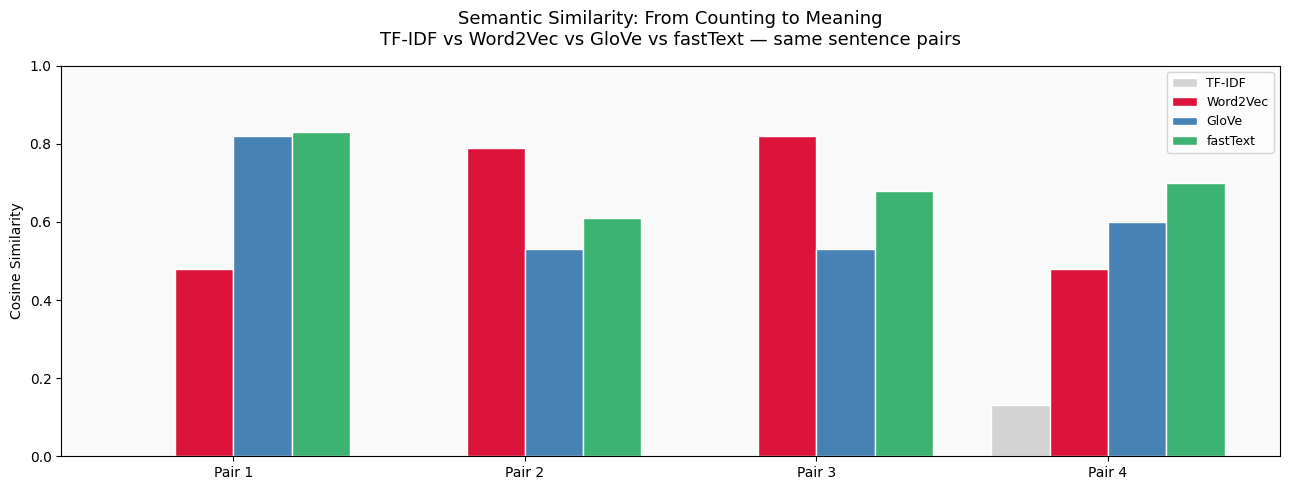

In [ ]:
# ── Semantic Similarity: All Three Models ────────────────────────────────────

from sklearn.feature_extraction.text import TfidfVectorizer

pairs = [
    ("students must maintain academic performance",
     "learners need to keep up their grades"),
    ("cheating will not be tolerated",
     "plagiarism leads to expulsion"),
    ("attend events to meet industry professionals",
     "fireside chats are good networking opportunities"),
    ("submit your project before the deadline",
     "late work will affect your score"),
]

def sent_vector(text, model_wv, vector_size):
    tokens  = preprocess(text)
    vectors = [model_wv[t] for t in tokens if t in model_wv]
    if not vectors:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# TF-IDF baseline
tfidf_vec = TfidfVectorizer()
all_sents = [s for pair in pairs for s in pair]
tfidf_vec.fit(all_sents)

print("── Semantic similarity: TF-IDF vs Word2Vec vs GloVe vs fastText ─────\n")

results = []
for s1, s2 in pairs:
    # TF-IDF
    t1, t2    = tfidf_vec.transform([s1]), tfidf_vec.transform([s2])
    tfidf_score = cosine_similarity(t1, t2)[0][0]

    # Word2Vec
    v1, v2    = (sent_vector(s, w2v_model.wv, 100).reshape(1,-1) for s in (s1, s2))
    w2v_score = cosine_similarity(v1, v2)[0][0]

    # GloVe
    v1, v2    = (sent_vector(s, glove_model, 100).reshape(1,-1) for s in (s1, s2))
    glove_score = cosine_similarity(v1, v2)[0][0]

    # fastText
    v1, v2    = (sent_vector(s, ft_model, 300).reshape(1,-1) for s in (s1, s2))
    ft_score  = cosine_similarity(v1, v2)[0][0]

    results.append({
        'Pair'    : f"{s1[:35]}…",
        'TF-IDF'  : round(tfidf_score, 2),
        'Word2Vec': round(w2v_score,   2),
        'GloVe'   : round(glove_score, 2),
        'fastText': round(ft_score,    2),
    })

results_df = pd.DataFrame(results).set_index('Pair')
print(results_df.to_string())

# ── Before/After Bar Chart ────────────────────────────────────────────────────

x      = np.arange(len(pairs))
width  = 0.2
labels = [f"Pair {i+1}" for i in range(len(pairs))]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - 1.5*width, results_df['TF-IDF'],   width, label='TF-IDF',   color='lightgrey',      edgecolor='white')
ax.bar(x - 0.5*width, results_df['Word2Vec'],  width, label='Word2Vec', color='crimson',        edgecolor='white')
ax.bar(x + 0.5*width, results_df['GloVe'],     width, label='GloVe',    color='steelblue',      edgecolor='white')
ax.bar(x + 1.5*width, results_df['fastText'],  width, label='fastText', color='mediumseagreen', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Cosine Similarity', fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Semantic Similarity: From Counting to Meaning\n'
             'TF-IDF vs Word2Vec vs GloVe vs fastText — same sentence pairs',
             fontsize=13, pad=15)
ax.legend(fontsize=9)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

## Final Summary

### What We Built

| Method | Approach | Meaning | OOV | Context-Aware |
|---|---|---|---|---|
| TF-IDF | Count + weight | No | No | No |
| Word2Vec | Learn from corpus | Yes | No | No |
| GloVe | Global co-occurrence | Yes | No | No |
| fastText | Subword composition | Yes | Yes | No |

### What We Proved on Real Data

- **TF-IDF** scored semantically equivalent sentences at **0.00**.
  No shared words means no similarity — regardless of meaning.
- **Word2Vec** trained on our small corpus improved scores but remained
  noisy — a direct consequence of limited training data.
- **GloVe and fastText**, trained on billions of words, produced consistently
  higher and more reliable semantic similarity scores across all four pairs.
- **fastText** handled domain-specific and misspelled words that left
  Word2Vec and GloVe with no vector at all.
- The **t-SNE document plot** showed that even with a small corpus,
  semantically related documents naturally gravitate toward each other
  in the embedding space — without ever being told their topic labels.

### The Remaining Ceiling

Every model in this notebook assigns **one fixed vector per word**,
regardless of context. The word `"dismissal"` gets the same vector whether
it appears in an academic policy document or a legal contract.

This is the final limitation that the next generation of models —
**Transformers like BERT** — were built to solve. By reading the entire
sentence before producing any embedding, they generate context-sensitive
representations where the same word gets a different vector in every sentence.

### The Bridge to the QA Bot

Everything we built in these two notebooks is the exact foundation of the
upcoming QA Bot project:

- **Preprocessing pipeline** → same tokenization and cleaning
- **TF-IDF vectors** → fast keyword-based document retrieval
- **Document vectors** → semantic similarity search across the knowledge base
- **Embedding models** → representing both the question and the documents
  in a shared semantic space so the right answer can be found

The QA bot is not a new idea — it is the logical next step of everything
you've already built.
